# Lab04: Tiền xử lý dữ liệu & đánh giá các kỹ thuật Feature Selection
**Dataset:** House Prices – Ames Housing (Kaggle) | **Bài toán:** hồi quy, dự đoán `SalePrice`
**Mô hình:** SVR (SVM), XGBoost, RandomForest 

## 1. Định nghĩa vấn đề (Define Problem)

- **Mô tả:** bộ dữ liệu Ames Housing gồm 1460 căn nhà (tệp `train.csv`), 79 biến giải thích và biến mục tiêu `SalePrice`.
- **Bài toán:** hồi quy – dự đoán giá nhà.
- **Mục tiêu Lab04:** tiền xử lý dữ liệu và đánh giá các kỹ thuật Feature Selection trên SVR, XGBoost và RandomForest.
- **Thang đo:** RMSE trên `log1p(SalePrice)`, R² và MAE (USD).

**Cơ sở từ Lab03 (EDA):**

| Phát hiện ở Lab03 | Xử lý ở Lab04 |
|---|---|
| `SalePrice` lệch phải | Biến đổi `log1p` cho biến mục tiêu |
| NA nghĩa là "không có hạng mục" | Điền `'None'` / 0 |
| Thiếu thật sự (`LotFrontage`, `Electrical`) | Điền bằng median trong Pipeline |
| Biến liên tục lệch mạnh | `log1p` các biến có `|skew| > 0.75` |
| Biến thứ bậc / định danh | Ordinal encoding / One-hot |
| Điểm ngoại lệ `GrLivArea` lớn nhưng giá thấp | Loại 2 điểm này |
| Đa cộng tuyến | Đánh giá bằng các phương pháp Feature Selection |



## 2. Chuẩn bị vấn đề (Prepare Problem)
### 2.1. Khai báo thư viện

In [1]:
import os, glob, time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from collections import Counter
from IPython.display import display
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, FunctionTransformer
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression, RFE, SelectFromModel
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, LassoCV
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor  

### 2.2. Tham số chương trình

In [2]:
RANDOM_STATE = 42
TEST_SIZE    = 0.2     # 20% dữ liệu để kiểm tra
N_FOLDS      = 5       # K-Fold trên tập train
K            = 40      # số đặc trưng giữ lại cho mỗi kỹ thuật chọn đặc trưng

### 2.3. Nạp dữ liệu (Load Dataset)

In [3]:
def find_data_dir():
    for c in ["./", "../input/house-prices-advanced-regression-techniques/",
              "/kaggle/input/house-prices-advanced-regression-techniques/"]:
        if os.path.exists(os.path.join(c, "train.csv")):
            return c
    hits = glob.glob("/kaggle/input/**/train.csv", recursive=True)
    if hits: return os.path.dirname(hits[0]) + "/"
    raise FileNotFoundError("Không tìm thấy train.csv - đặt cùng thư mục notebook.")

DATA_DIR = find_data_dir()
raw = pd.read_csv(DATA_DIR + "train.csv")
print("Kích thước train:", raw.shape)
raw.head()

Kích thước train: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. Tiền xử lý dữ liệu (Data Preprocessing)
### 3.1. Làm sạch dữ liệu (Data Cleaning)
Các bước dưới đây **không học thông tin từ dữ liệu** (không tính trung bình/trung vị...) nên làm trước khi chia tập mà không gây rò rỉ dữ liệu (data leakage).

#### a) Xóa cột không cần, dữ liệu trùng, ngoại lệ

In [ ]:
df = raw.copy()
df = df.drop(columns=['Id'])               
print("Số dòng trùng nhau:", df.duplicated().sum())
df = df.drop_duplicates()

# Ngoại lệ đã thấy ở Lab03: diện tích rất lớn nhưng giá thấp bất thường
out_mask = (df.GrLivArea > 4000) & (df.SalePrice < 300000)
print("Số điểm ngoại lệ loại bỏ:", out_mask.sum())
df = df[~out_mask].reset_index(drop=True)
print("Kích thước sau khi làm sạch:", df.shape)

Số dòng trùng nhau: 0
Số điểm ngoại lệ loại bỏ: 2
Kích thước sau khi làm sạch: (1458, 80)


#### b) Phân tích giá trị thiếu

In [5]:
miss = raw.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
miss_df = pd.DataFrame({'số NA': miss, '% NA': (miss / len(raw) * 100).round(1)})
miss_df

,số NA,% NA
PoolQC,1453,99.5
MiscFeature,1406,96.3
Alley,1369,93.8
Fence,1179,80.8
MasVnrType,872,59.7
FireplaceQu,690,47.3
LotFrontage,259,17.7
GarageType,81,5.5
GarageYrBlt,81,5.5
GarageFinish,81,5.5


In [ ]:
none_cols = ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu','GarageType','GarageFinish','GarageQual',
             'GarageCond','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','MasVnrType']
for c in none_cols: df[c] = df[c].fillna('None')
for c in ['GarageYrBlt','MasVnrArea']: df[c] = df[c].fillna(0)

still = df.isna().sum(); still = still[still > 0]
print("Cột còn thiếu thật sự sau bước này:"); print(still)

tmp = df.assign(LotFrontage_missing=df.LotFrontage.isna())
for c in ['LotShape', 'LotConfig']:
    print(f"\nTỉ lệ thiếu LotFrontage theo {c}:")
    print(tmp.groupby(c).LotFrontage_missing.agg(['mean', 'size']).round(3))

Cột còn thiếu thật sự sau bước này:
LotFrontage    259
Electrical       1
dtype: int64

Tỉ lệ thiếu LotFrontage theo LotShape:
           mean  size
LotShape             
IR1       0.346   483
IR2       0.366    41
IR3       0.333     9
Reg       0.080   925

Tỉ lệ thiếu LotFrontage theo LotConfig:
            mean  size
LotConfig             
Corner     0.237   262
CulDSac    0.521    94
FR2        0.298    47
FR3        0.000     4
Inside     0.127  1051


### 3.2. Tạo đặc trưng mới (Feature Construction – many-to-one)
Theo ML-04b, kết hợp nhiều đặc trưng cơ bản thành đặc trưng mới có thể phản ánh quan hệ giữa chúng.

In [ ]:
df['TotalSF']       = df.TotalBsmtSF + df['1stFlrSF'] + df['2ndFlrSF']
df['TotalBath']     = df.FullBath + 0.5*df.HalfBath + df.BsmtFullBath + 0.5*df.BsmtHalfBath
df['HouseAge']      = (df.YrSold - df.YearBuilt).clip(lower=0)
df['RemodAge']      = (df.YrSold - df.YearRemodAdd).clip(lower=0)
df['HasGarage']     = (df.GarageArea > 0).astype(int)
df['HasBsmt']       = (df.TotalBsmtSF > 0).astype(int)
df['HasPool']       = (df.PoolArea > 0).astype(int)
df['HasFireplace']  = (df.Fireplaces > 0).astype(int)
df['MSSubClass']    = df['MSSubClass'].astype(str)
print("Sau khi tạo đặc trưng:", df.shape)

Sau khi tạo đặc trưng: (1458, 88)


### 3.3. Mã hóa biến thứ bậc (ordinal)
Chuyển các biến chất lượng thành số theo đúng thứ tự (Po < Fa < TA < Gd < Ex), giữ được thông tin thứ bậc. (Biến định danh sẽ được one-hot trong Pipeline.)

In [8]:
qual = {'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5}
fin  = {'None':0,'Unf':1,'LwQ':2,'Rec':3,'BLQ':4,'ALQ':5,'GLQ':6}
ord_maps = {c: qual for c in ['ExterQual','ExterCond','BsmtQual','BsmtCond','HeatingQC','KitchenQual',
                              'FireplaceQu','GarageQual','GarageCond','PoolQC']}
ord_maps.update({
    'BsmtExposure': {'None':0,'No':1,'Mn':2,'Av':3,'Gd':4},
    'BsmtFinType1': fin, 'BsmtFinType2': fin,
    'GarageFinish': {'None':0,'Unf':1,'RFn':2,'Fin':3},
    'LotShape':     {'IR3':0,'IR2':1,'IR1':2,'Reg':3},
    'LandSlope':    {'Sev':0,'Mod':1,'Gtl':2},
    'PavedDrive':   {'N':0,'P':1,'Y':2},
    'CentralAir':   {'N':0,'Y':1},
    'Fence':        {'None':0,'MnWw':1,'GdWo':2,'MnPrv':3,'GdPrv':4},
    'Functional':   {'Sal':0,'Sev':1,'Maj2':2,'Maj1':3,'Mod':4,'Min2':5,'Min1':6,'Typ':7},
})
for c, m in ord_maps.items(): df[c] = df[c].map(m)

# Biến mục tiêu: log1p (SalePrice lệch phải - Lab03)
y = np.log1p(df.pop('SalePrice'))
X = df
print(f"Skew SalePrice gốc: {raw.SalePrice.skew():.2f} -> sau log1p: {y.skew():.2f}")

Skew SalePrice gốc: 1.88 -> sau log1p: 0.12


### 3.4. Chia dữ liệu thực nghiệm
Chia dữ liệu thành tập huấn luyện và tập kiểm tra trước khi học các tham số tiền xử lý.

In [9]:
cat_cols = X.select_dtypes('object').columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
kf = KFold(N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Biến số:", len(num_cols), "| Biến phân loại (nominal):", len(cat_cols))

skewed = [c for c in num_cols if X_train[c].nunique() > 15 and abs(X_train[c].skew()) > 0.75]
print("Số biến liên tục lệch mạnh:", len(skewed))

Train: (1166, 87) | Test: (292, 87)
Biến số: 63 | Biến phân loại (nominal): 24
Số biến liên tục lệch mạnh: 18


### 3.5. Biến đổi dữ liệu bằng Pipeline
Dùng Pipeline và ColumnTransformer để mọi bước học tham số chỉ diễn ra trên tập huấn luyện, tránh rò rỉ dữ liệu.

In [10]:
def make_num_imputer(kind='median'):
    if kind != 'median':
        raise ValueError("Chỉ hỗ trợ median trong phiên bản rút gọn này")
    return SimpleImputer(strategy='median')

def make_scaler(kind='minmax'):
    return {'standard': StandardScaler(), 'minmax': MinMaxScaler(), 'none': 'passthrough'}[kind]

def make_preprocessor(imputer='median', scaler='minmax'):
    num_skew = Pipeline([
        ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
        ('sc', make_scaler(scaler)),
        ('imp', make_num_imputer(imputer))
    ])
    num_norm = Pipeline([
        ('sc', make_scaler(scaler)),
        ('imp', make_num_imputer(imputer))
    ])
    cat = Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('oh', OneHotEncoder(handle_unknown='ignore', min_frequency=10, sparse_output=False))
    ])
    rest = [c for c in num_cols if c not in skewed]
    return ColumnTransformer([
        ('skew', num_skew, skewed),
        ('num', num_norm, rest),
        ('cat', cat, cat_cols)
    ])

pre = make_preprocessor().fit(X_train)
feat_names = pre.get_feature_names_out()
A = pre.transform(X_train)
print("Số đặc trưng sau tiền xử lý:", A.shape[1], "| NaN còn lại:", int(np.isnan(A).sum()))

Số đặc trưng sau tiền xử lý: 204 | NaN còn lại: 0


### 3.6. Mô hình và hàm đánh giá dùng chung

In [11]:
def get_models():
    return {
     'SVR':          SVR(C=3, epsilon=0.05, gamma='scale'),
     'XGBoost':      XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, subsample=0.8,
                                  colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1),
     'RandomForest': RandomForestRegressor(200, max_features=0.33, random_state=RANDOM_STATE, n_jobs=-1),
    }

def cv_rmse(pipe):
    return -cross_val_score(pipe, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error').mean()

## 4. Các kỹ thuật Feature Selection
Từ ~200 đặc trưng sau tiền xử lý, mỗi kỹ thuật giữ **K = 40** đặc trưng. Bộ **Baseline** dùng toàn bộ. (Kiểm định chi-squared ở Ch.8 chỉ dùng cho bài toán phân loại với đặc trưng không âm nên không áp dụng cho hồi quy; ta dùng `f_regression` và Mutual Information thay thế.)

| Nhóm | Kỹ thuật | Ý tưởng |
|---|---|---|
| Filter (Univariate) | `f_regression` | Điểm F (tương quan tuyến tính với target) |
| Filter (Univariate) | Mutual Information | Phụ thuộc phi tuyến với target |
| Wrapper | RFE (Ridge) | Loại dần đặc trưng kém quan trọng nhất |
| Embedded | Lasso (L1) | Hệ số bị ép về 0 |
| Embedded | RandomForest importance | Độ quan trọng từ rừng ngẫu nhiên |
| Embedded | ExtraTrees importance | Độ quan trọng từ ExtraTrees (như Ch.8) |
| Extraction | PCA (40 thành phần) | Biến đổi thành 40 thành phần mới, **không** giữ đặc trưng gốc |

In [12]:
def get_selectors(k=K):
    return {
     'Baseline (all)':               'passthrough',
     'Filter: f_regression':         SelectKBest(f_regression, k=k),
     'Filter: Mutual Info':          SelectKBest(lambda X, y: mutual_info_regression(X, y, random_state=RANDOM_STATE), k=k),
     'Wrapper: RFE (Ridge)':         RFE(Ridge(alpha=10), n_features_to_select=k, step=10),
     'Embedded: Lasso':              SelectFromModel(LassoCV(cv=3, random_state=RANDOM_STATE, max_iter=5000),
                                                     max_features=k, threshold=-np.inf),
     'Embedded: RF importance':      SelectFromModel(RandomForestRegressor(100, random_state=RANDOM_STATE, n_jobs=-1),
                                                     max_features=k, threshold=-np.inf),
     'Embedded: ExtraTrees importance': SelectFromModel(ExtraTreesRegressor(200, random_state=RANDOM_STATE, n_jobs=-1),
                                                     max_features=k, threshold=-np.inf),
     'Extraction: PCA':              PCA(n_components=k, random_state=RANDOM_STATE),
    }

## 5. Thực nghiệm

In [ ]:
def evaluate(pipe, name_sel, name_model, n_feat):
    cv = cv_rmse(pipe)
    t = time.time(); pipe.fit(X_train, y_train); fit_time = time.time() - t
    pred = pipe.predict(X_test)
    return {'Selection': name_sel, 'Model': name_model, 'n_features': n_feat,
            'CV_RMSE(log)': cv,
            'Test_RMSE(log)': np.sqrt(mean_squared_error(y_test, pred)),
            'Test_R2': r2_score(y_test, pred),
            'Test_MAE($)': mean_absolute_error(np.expm1(y_test), np.expm1(pred)),
            'Fit_time(s)': fit_time}

rows = []
for sn, s in get_selectors().items():
    for mn, m in get_models().items():
        pipe = Pipeline([('pre', make_preprocessor()), ('sel', s), ('model', m)])
        n_feat = A.shape[1] if sn.startswith('Baseline') else K
        rows.append(evaluate(pipe, sn, mn, n_feat))
        print(f"{sn:34s} {mn:13s} CV_RMSE={rows[-1]['CV_RMSE(log)']:.4f}  Test_R2={rows[-1]['Test_R2']:.4f}")
results = pd.DataFrame(rows)

Baseline (all)                     SVR           CV_RMSE=0.1233  Test_R2=0.9047
Baseline (all)                     XGBoost       CV_RMSE=0.1167  Test_R2=0.9236
Baseline (all)                     RandomForest  CV_RMSE=0.1303  Test_R2=0.8868
Filter: f_regression               SVR           CV_RMSE=0.1418  Test_R2=0.8738
Filter: f_regression               XGBoost       CV_RMSE=0.1314  Test_R2=0.8877


### 5.1. Bảng kết quả

In [ ]:
results.round(4)

,Selection,Model,n_features,CV_RMSE(log),Test_RMSE(log),Test_R2,Test_MAE($),Fit_time(s)
0,Baseline (all),SVR,204,0.1233,0.1267,0.9047,15126.7499,0.1417
1,Baseline (all),XGBoost,204,0.1167,0.1135,0.9236,13887.6798,0.5244
2,Baseline (all),RandomForest,204,0.1303,0.1381,0.8868,15022.6475,0.3913
3,Filter: f_regression,SVR,40,0.1418,0.1459,0.8738,16730.0386,0.1344
4,Filter: f_regression,XGBoost,40,0.1314,0.1376,0.8877,15159.2362,0.2599
5,Filter: f_regression,RandomForest,40,0.1349,0.1481,0.8699,16378.9075,0.3606
6,Filter: Mutual Info,SVR,40,0.1398,0.1357,0.8908,16087.1329,1.3109
7,Filter: Mutual Info,XGBoost,40,0.1255,0.1279,0.9030,14578.0100,1.4240
8,Filter: Mutual Info,RandomForest,40,0.1325,0.1444,0.8763,15613.3512,1.4248
9,Wrapper: RFE (Ridge),SVR,40,0.1228,0.1093,0.9291,12933.7630,0.2249


In [ ]:
order = list(get_selectors())
pivot_rmse = results.pivot(index='Selection', columns='Model', values='CV_RMSE(log)').loc[order][list(get_models())]
pivot_r2   = results.pivot(index='Selection', columns='Model', values='Test_R2').loc[order][list(get_models())]
pivot_mae  = results.pivot(index='Selection', columns='Model', values='Test_MAE($)').loc[order][list(get_models())]
pivot_time = results.pivot(index='Selection', columns='Model', values='Fit_time(s)').loc[order][list(get_models())]
display(pivot_rmse.round(4).style.background_gradient(cmap='RdYlGn_r', axis=None).set_caption('CV RMSE (log) - thấp hơn là tốt hơn'))
display(pivot_r2.round(4).style.background_gradient(cmap='RdYlGn', axis=None).set_caption('Test R2 - cao hơn là tốt hơn'))
display(pivot_mae.round(0).style.background_gradient(cmap='RdYlGn_r', axis=None).set_caption('Test MAE ($) - thấp hơn là tốt hơn'))
display(pivot_time.round(2).style.set_caption('Thời gian huấn luyện lần cuối (giây)'))

Model,SVR,XGBoost,RandomForest
Selection,,,
Baseline (all),0.123300,0.116700,0.130300
Filter: f_regression,0.141800,0.131400,0.134900
Filter: Mutual Info,0.139800,0.125500,0.132500
Wrapper: RFE (Ridge),0.122800,0.117300,0.130200
Embedded: Lasso,0.126400,0.118700,0.131700
Embedded: RF importance,0.134300,0.122200,0.132100
Embedded: ExtraTrees importance,0.129200,0.121200,0.129100
Extraction: PCA,0.158400,0.165100,0.187000


Model,SVR,XGBoost,RandomForest
Selection,,,
Baseline (all),0.904700,0.923600,0.886800
Filter: f_regression,0.873800,0.887700,0.869900
Filter: Mutual Info,0.890800,0.903000,0.876300
Wrapper: RFE (Ridge),0.929100,0.917300,0.882200
Embedded: Lasso,0.928000,0.917300,0.888100
Embedded: RF importance,0.895900,0.905100,0.882500
Embedded: ExtraTrees importance,0.905100,0.914800,0.883400
Extraction: PCA,0.841200,0.805600,0.766700


Model,SVR,XGBoost,RandomForest
Selection,,,
Baseline (all),15127.000000,13888.000000,15023.000000
Filter: f_regression,16730.000000,15159.000000,16379.000000
Filter: Mutual Info,16087.000000,14578.000000,15613.000000
Wrapper: RFE (Ridge),12934.000000,13683.000000,15779.000000
Embedded: Lasso,13813.000000,14204.000000,15682.000000
Embedded: RF importance,15218.000000,14859.000000,15448.000000
Embedded: ExtraTrees importance,14543.000000,13928.000000,15583.000000
Extraction: PCA,19315.000000,23005.000000,24898.000000


Model,SVR,XGBoost,RandomForest
Selection,,,
Baseline (all),0.140000,0.520000,0.390000
Filter: f_regression,0.130000,0.260000,0.360000
Filter: Mutual Info,1.310000,1.420000,1.420000
Wrapper: RFE (Ridge),0.220000,0.320000,0.420000
Embedded: Lasso,0.330000,0.440000,0.550000
Embedded: RF importance,0.510000,0.630000,0.810000
Embedded: ExtraTrees importance,0.900000,0.990000,1.090000
Extraction: PCA,0.190000,0.350000,0.440000


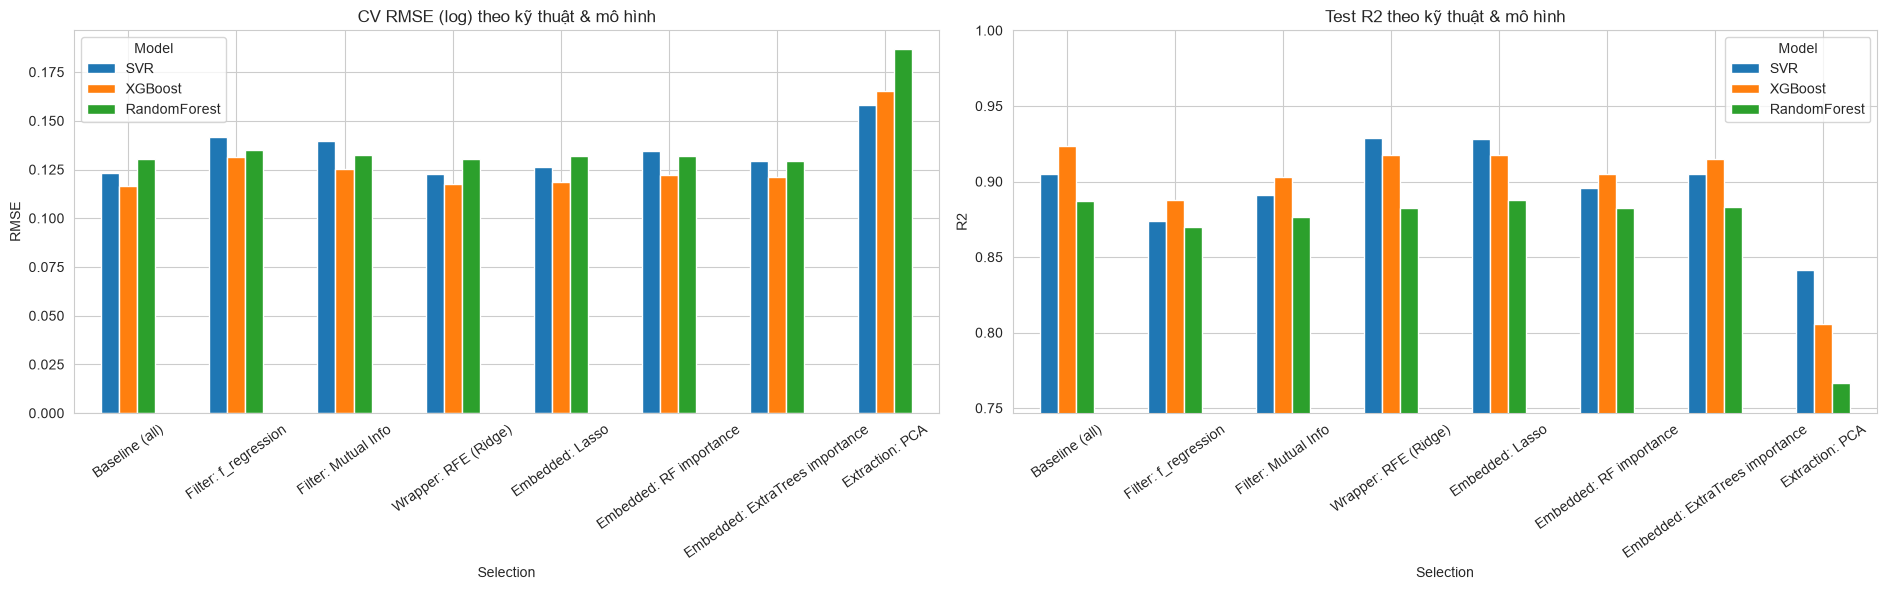

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(19, 6))
pivot_rmse.plot.bar(ax=axes[0], rot=35); axes[0].set_title('CV RMSE (log) theo kỹ thuật & mô hình'); axes[0].set_ylabel('RMSE')
pivot_r2.plot.bar(ax=axes[1], rot=35);   axes[1].set_title('Test R2 theo kỹ thuật & mô hình');        axes[1].set_ylabel('R2')
axes[1].set_ylim(pivot_r2.values.min() - 0.02, 1)
plt.tight_layout(); plt.show()

In [ ]:
# Cấu hình tốt nhất cho mỗi mô hình và so với Baseline
best = results.loc[results.groupby('Model')['CV_RMSE(log)'].idxmin(), ['Model', 'Selection', 'CV_RMSE(log)', 'Test_R2']].set_index('Model')
base = results[results.Selection.str.startswith('Baseline')].set_index('Model')[['CV_RMSE(log)', 'Test_R2']].add_prefix('Baseline_')
best.join(base).round(4)

,Selection,CV_RMSE(log),Test_R2,Baseline_CV_RMSE(log),Baseline_Test_R2
Model,,,,,
RandomForest,Embedded: ExtraTrees importance,0.1291,0.8834,0.1303,0.8868
SVR,Wrapper: RFE (Ridge),0.1228,0.9291,0.1233,0.9047
XGBoost,Baseline (all),0.1167,0.9236,0.1167,0.9236


### 5.2. Các đặc trưng được chọn bởi từng kỹ thuật

In [ ]:
selected = {}
for sn, s in get_selectors().items():
    if sn.startswith('Baseline') or sn.startswith('Extraction'): continue 
    s.fit(A, y_train)
    selected[sn] = set(feat_names[s.get_support()])

for sn, feats in selected.items():
    print(f"\n{sn} ({len(feats)}):", ', '.join(sorted(f.split('__')[-1] for f in feats)))


Filter: f_regression (40): 1stFlrSF, BsmtExposure, BsmtQual, CentralAir, ExterQual, FireplaceQu, Fireplaces, Foundation_PConc, FullBath, GarageArea, GarageCars, GarageCond, GarageFinish, GarageQual, GarageType_Attchd, GarageType_Detchd, GarageType_None, GarageYrBlt, GrLivArea, HasFireplace, HeatingQC, HouseAge, KitchenQual, LotArea, LotFrontage, MSSubClass_60, MSZoning_RM, MasVnrArea, MasVnrType_None, Neighborhood_NridgHt, OpenPorchSF, OverallQual, RemodAge, TotRmsAbvGrd, TotalBath, TotalBsmtSF, TotalSF, WoodDeckSF, YearBuilt, YearRemodAdd

Filter: Mutual Info (40): 1stFlrSF, 2ndFlrSF, BsmtFinSF1, BsmtFinType1, BsmtQual, BsmtUnfSF, ExterQual, Exterior2nd_VinylSd, FireplaceQu, Fireplaces, Foundation_CBlock, Foundation_PConc, FullBath, GarageArea, GarageCars, GarageFinish, GarageType_Attchd, GarageType_Detchd, GarageYrBlt, GrLivArea, HalfBath, HasFireplace, HeatingQC, HouseAge, KitchenQual, LotArea, LotFrontage, MSSubClass_60, MasVnrArea, MasVnrType_None, OpenPorchSF, OverallCond, Overa

In [ ]:
# Đặc trưng được nhiều kỹ thuật cùng chọn = ổn định/quan trọng
cnt = Counter(f for feats in selected.values() for f in feats)
common = pd.DataFrame(cnt.most_common(20), columns=['feature', 'số kỹ thuật chọn'])
common['feature'] = common['feature'].str.split('__').str[-1]
common

,feature,số kỹ thuật chọn
0,HouseAge,6
1,GarageArea,6
2,TotalBsmtSF,6
3,RemodAge,6
4,BsmtQual,6
5,KitchenQual,6
6,LotArea,6
7,OverallQual,6
8,1stFlrSF,6
9,GrLivArea,6
